# SVM vs Random Forest - CICIDS2017 (SMOTE Balanced)
Benchmark on cleaned CICIDS2017 dataset with SMOTE resampling and 70-30 train/test split

In [1]:
!pip install imbalanced-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load Data

In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load cleaned CICIDS2017 dataset from Google Drive
# UPDATE THIS PATH to match where your CSV is stored in Drive
df = pd.read_csv('/content/drive/MyDrive/data_processed/cicids2017_cleaned.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")
print(f"\nDataset Info:")
print(df.info())
print(f"\nOriginal Class Distribution:")
print(df['Label'].value_counts())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (2520798, 79)
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520798 entries, 0 to 2520797
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             float64
 1   Flow Duration                float64
 2   Total Fwd Packets            float64
 3   Total Backward Packets       float64
 4   Total Length of Fwd Packets  float64
 5   Total Length of Bwd Packets  float64
 6   Fwd Packet Length Max        float64
 7   Fwd Packet Length Min        float64
 8   Fwd Packet Length Mean       

## Step 2: Prepare Train/Test Split (70-30)

In [6]:
# Separate features and labels
X = df.drop('Label', axis=1)
y = df['Label']

print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

# 70-30 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution (BEFORE resampling):")
print(y_train.value_counts())

Total features: 78
Total samples: 2520798

Train set: 1764558 samples
Test set: 756240 samples

Training set class distribution (BEFORE resampling):
Label
0     1466539
4      120992
2       89610
10      63486
3        7200
7        4152
6        3769
5        3660
11       2253
1        1364
12       1029
14        456
9          25
13         15
8           8
Name: count, dtype: int64


## Step 3: Apply SMOTE + Undersampling to Balance Training Data

In [7]:
threshold = 10286

print("=" * 60)
print("RESAMPLING TRAINING DATA")
print("=" * 60)
print(f"\nStrategy:")
print(f"  - Classes ABOVE {threshold} samples → Undersample to 50,000")
print(f"  - Classes BELOW {threshold} samples → SMOTE oversample (count + 200)")

# Step 1: Undersample large classes to 50,000
under_strategy = {}
for label, count in Counter(y_train).items():
    if count > threshold:
        under_strategy[label] = 50000

print(f"\nUndersampling classes: {list(under_strategy.keys())}")

under_sampler = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_train_resampled, y_train_resampled = under_sampler.fit_resample(X_train, y_train)

print(f"After undersampling: {len(y_train_resampled):,} samples")

# Step 2: SMOTE oversample small classes (count + 200)
over_strategy = {}
for label, count in Counter(y_train_resampled).items():
    if count < threshold:
        over_strategy[label] = count + 200

print(f"SMOTE oversampling classes: {list(over_strategy.keys())}")

smote = SMOTE(sampling_strategy=over_strategy, random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_resampled, y_train_resampled)

print(f"After SMOTE: {len(y_train_resampled):,} samples")
print(f"\nFinal Training set class distribution (AFTER resampling):")
print(pd.Series(y_train_resampled).value_counts())

RESAMPLING TRAINING DATA

Strategy:
  - Classes ABOVE 10286 samples → Undersample to 50,000
  - Classes BELOW 10286 samples → SMOTE oversample (count + 200)

Undersampling classes: [4, 0, 2, 10]
After undersampling: 223,931 samples
SMOTE oversampling classes: [1, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14]
After SMOTE: 226,131 samples

Final Training set class distribution (AFTER resampling):
Label
0     50000
2     50000
4     50000
10    50000
3      7400
7      4352
6      3969
5      3860
11     2453
1      1564
12     1229
14      656
9       225
13      215
8       208
Name: count, dtype: int64


## Step 4: Scale Features

In [8]:
# Standardize features (fit on resampled training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled successfully!")
print(f"Train mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"Test mean: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")

Features scaled successfully!
Train mean: 0.0000, std: 0.9473
Test mean: -2.1054, std: 10072.0262


## Step 5: Train SVM (SGDClassifier with Hinge Loss)

In [10]:
print("Training SVM (SGDClassifier with Hinge Loss)...")
svm_model = SGDClassifier(
    loss='hinge',
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    tol=1e-3,
    n_jobs=-1
)
svm_model.fit(X_train_scaled, y_train_resampled)

# Predictions
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)

# Metrics
svm_metrics = {
    'Algorithm': 'SVM (SGDClassifier - Hinge Loss)',
    'Train Accuracy': accuracy_score(y_train_resampled, y_train_pred_svm),
    'Test Accuracy': accuracy_score(y_test, y_test_pred_svm),
    'Precision': precision_score(y_test, y_test_pred_svm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_test_pred_svm, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_test_pred_svm, average='weighted', zero_division=0)
}

print(f"SVM Training Complete!")
print(f"  Train Accuracy: {svm_metrics['Train Accuracy']:.4f}")
print(f"  Test Accuracy: {svm_metrics['Test Accuracy']:.4f}")
print(f"  Precision: {svm_metrics['Precision']:.4f}")
print(f"  Recall: {svm_metrics['Recall']:.4f}")
print(f"  F1-Score: {svm_metrics['F1-Score']:.4f}")

Training SVM (SGDClassifier with Hinge Loss)...
SVM Training Complete!
  Train Accuracy: 0.9496
  Test Accuracy: 0.8880
  Precision: 0.9609
  Recall: 0.8880
  F1-Score: 0.9179


## Step 6: Train Random Forest

In [11]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced_subsample')
rf_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_resampled)
y_test_pred_rf = rf_model.predict(X_test)

# Metrics
rf_metrics = {
    'Algorithm': 'Random Forest',
    'Train Accuracy': accuracy_score(y_train_resampled, y_train_pred_rf),
    'Test Accuracy': accuracy_score(y_test, y_test_pred_rf),
    'Precision': precision_score(y_test, y_test_pred_rf, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_test_pred_rf, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_test_pred_rf, average='weighted', zero_division=0)
}

print(f"Random Forest Training Complete!")
print(f"  Train Accuracy: {rf_metrics['Train Accuracy']:.4f}")
print(f"  Test Accuracy: {rf_metrics['Test Accuracy']:.4f}")
print(f"  Precision: {rf_metrics['Precision']:.4f}")
print(f"  Recall: {rf_metrics['Recall']:.4f}")
print(f"  F1-Score: {rf_metrics['F1-Score']:.4f}")

Training Random Forest...
Random Forest Training Complete!
  Train Accuracy: 1.0000
  Test Accuracy: 0.9979
  Precision: 0.9981
  Recall: 0.9979
  F1-Score: 0.9980


## Step 7: Compare Results (Table)

In [12]:
# Create comparison dataframe
comparison_df = pd.DataFrame([svm_metrics, rf_metrics])
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON (SMOTE Balanced Dataset)")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL PERFORMANCE COMPARISON (SMOTE Balanced Dataset)
                       Algorithm  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score
SVM (SGDClassifier - Hinge Loss)        0.949613       0.888033   0.960858 0.888033  0.917859
                   Random Forest        0.999969       0.997892   0.998087 0.997892  0.997952


## Step 8: Visualize Metrics (Line Plot)

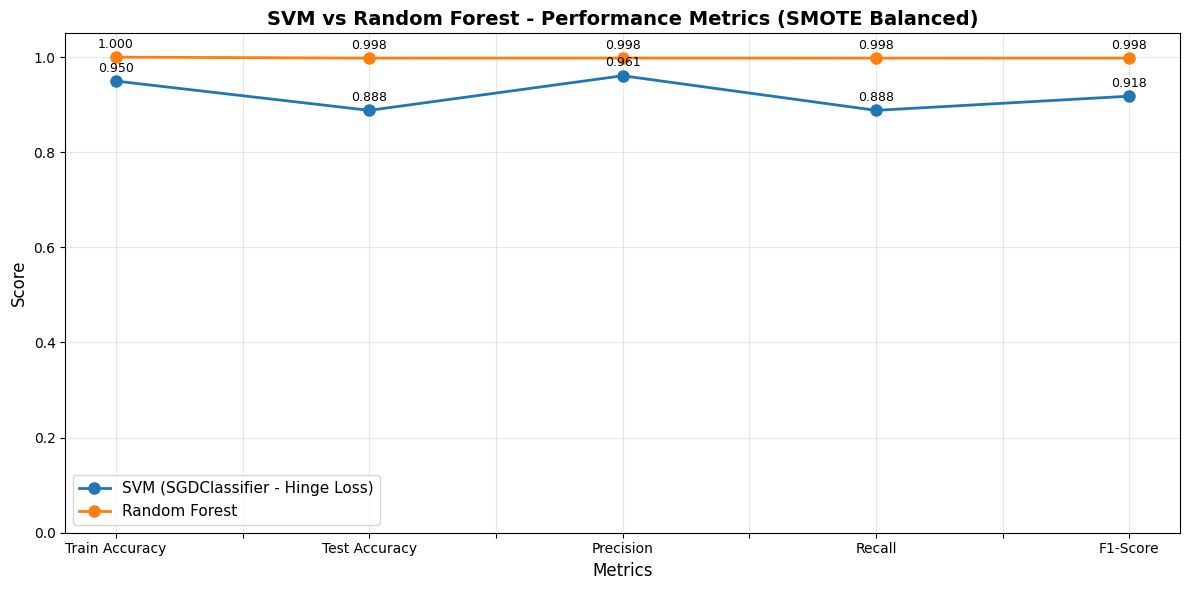

In [13]:
# Prepare data for visualization
metrics_data = comparison_df.set_index('Algorithm').T

# Plot 1: Line plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_data.plot(ax=ax, marker='o', linewidth=2, markersize=8)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metrics', fontsize=12)
ax.set_title('SVM vs Random Forest - Performance Metrics (SMOTE Balanced)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add value labels on points
for col in metrics_data.columns:
    for idx, val in enumerate(metrics_data[col]):
        ax.text(idx, val + 0.02, f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Step 9: Visualize Metrics (Bar Plot)

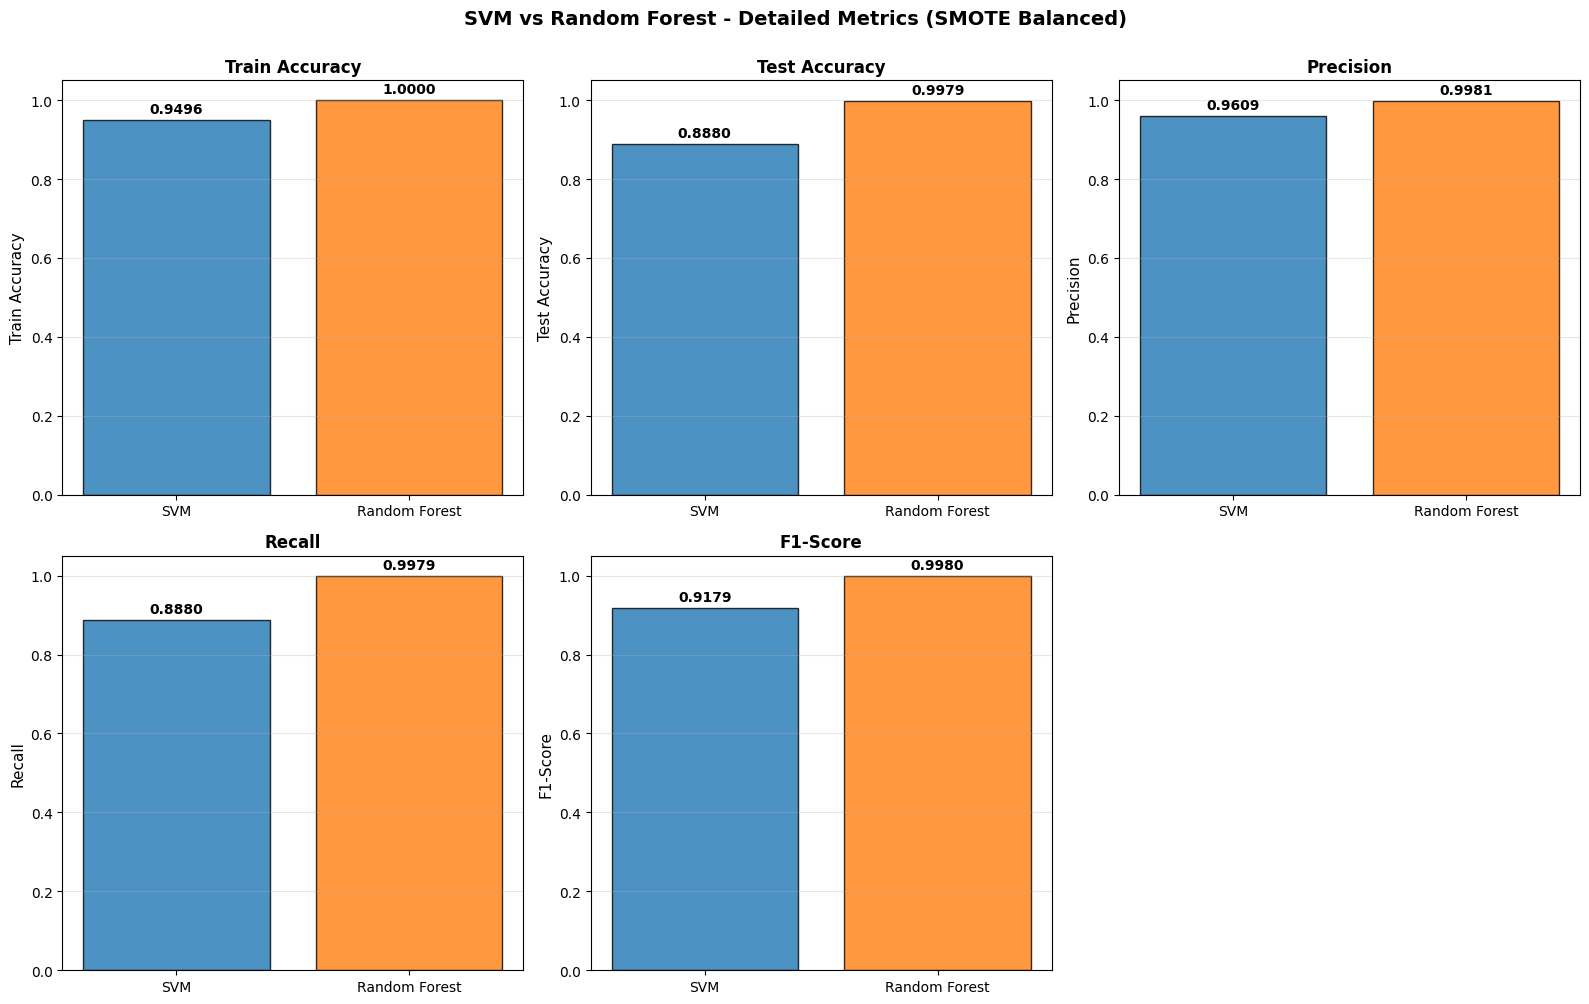

In [14]:
# Plot 2: Bar plot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

metrics_to_plot = ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = [svm_metrics[metric], rf_metrics[metric]]
    bars = ax.bar(['SVM', 'Random Forest'], values, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim([0, 1.05])
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Remove extra subplot
fig.delaxes(axes[5])

fig.suptitle('SVM vs Random Forest - Detailed Metrics (SMOTE Balanced)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Step 10: Confusion Matrices

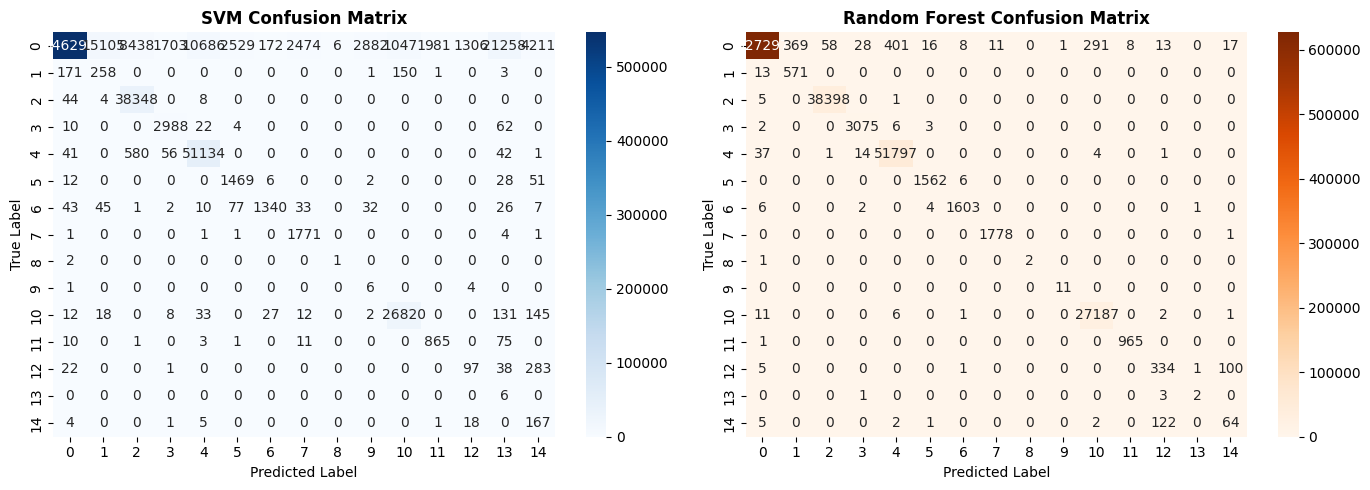

In [15]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_title('SVM Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=True)
axes[1].set_title('Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Step 11: Classification Reports

In [16]:
print("\n" + "="*80)
print("SVM - CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_test_pred_svm, zero_division=0))

print("\n" + "="*80)
print("RANDOM FOREST - CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_test_pred_rf, zero_division=0))


SVM - CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    628518
           1       0.02      0.44      0.03       584
           2       0.81      1.00      0.89     38404
           3       0.63      0.97      0.76      3086
           4       0.83      0.99      0.90     51854
           5       0.36      0.94      0.52      1568
           6       0.87      0.83      0.85      1616
           7       0.41      1.00      0.58      1779
           8       0.14      0.33      0.20         3
           9       0.00      0.55      0.00        11
          10       0.72      0.99      0.83     27208
          11       0.47      0.90      0.61       966
          12       0.07      0.22      0.10       441
          13       0.00      1.00      0.00         6
          14       0.03      0.85      0.07       196

    accuracy                           0.89    756240
   macro avg       0.42      0.79      0.49    7562

## Step 12: Summary

In [ ]:
print("\n" + "#"*80)
print("# SUMMARY")
print("#"*80)

best_f1 = 'SVM' if svm_metrics['F1-Score'] > rf_metrics['F1-Score'] else 'Random Forest'
best_acc = 'SVM' if svm_metrics['Test Accuracy'] > rf_metrics['Test Accuracy'] else 'Random Forest'

print(f"\nDataset: CICIDS2017 (Cleaned + SMOTE Balanced)")
print(f"Total Samples (Original): {len(df):,}")
print(f"Total Training Samples (After SMOTE): {len(y_train_resampled):,}")
print(f"Total Features: {X.shape[1]}")
print(f"Train/Test Split: 70/30")
print(f"Test Samples: {len(X_test):,}")
print(f"\nResampling Strategy:")
print(f"  - Classes > {threshold} samples: Undersampled to 50,000")
print(f"  - Classes < {threshold} samples: SMOTE oversampled (count + 200)")

print(f"\n" + "-"*80)
print(f"BEST MODEL (by Test Accuracy): {best_acc}")
print(f"BEST MODEL (by F1-Score): {best_f1}")
print(f"-"*80)

print(f"\nSVM Performance:")
for key, value in svm_metrics.items():
    if key != 'Algorithm':
        print(f"  {key}: {value:.4f}")

print(f"\nRandom Forest Performance:")
for key, value in rf_metrics.items():
    if key != 'Algorithm':
        print(f"  {key}: {value:.4f}")

print(f"\n" + "#"*80)

## Step 13: Save Models to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib
import os

save_path = '/content/drive/MyDrive/IDS_Project/saved_models_smote'
os.makedirs(save_path, exist_ok=True)

joblib.dump(svm_model, f'{save_path}/svm_model_smote.pkl')
joblib.dump(rf_model, f'{save_path}/rf_model_smote.pkl')
joblib.dump(scaler, f'{save_path}/scaler_smote.pkl')

print("All models saved to Google Drive!")
print(f"Location: {save_path}")